# Deteksi Phishing URL — XGBoost + PhiUSIIL (Model GABUNGAN URL + HTML)

`skripsi_final` fokus menghasilkan **model FULL (URL + HTML)**. Model URL-only juga dijalankan **sebagai pembanding** (pkl-nya dari `skripsi.ipynb`).

**Konstruksi fitur:**
- **Fitur URL** = **41 fitur leksikal** dari `url_features.py` (dihitung dari string URL) → konsisten dengan backend.
- **Fitur HTML** = kolom **konten STABIL** dari dataset (`HasTitle`, `HasPasswordField`, `HasExternalFormSubmit`, dll). Fitur HTML rapuh (`NoOfCSS`, dll) & leakage dibuang.

**Seleksi fitur:**
- Model FULL → **RFECV** pada **semua fitur** (URL + HTML digabung), jumlah fitur dipilih otomatis. (Metode yang sama dieksplorasi di sel **3c**; di pipeline dijalankan pada **data training saja** agar bebas leakage.)
- Model URL-only → RFECV pada fitur URL.

**Lain-lain:** split **per-domain**, tuning **GroupKFold**, threshold via **balanced accuracy**, `scale_pos_weight=1`, metrik fokus **phishing** (label 0).

> Export: **hanya model FULL** → `model_xgboost_dataset.pkl` + `dataset_feature_schema.pkl` + `dataset_threshold.pkl`. Backend (`app.py`) jalur FULL = `extract_url_features` + `scrape_html_features` (digabung); fallback = model URL-only.

In [1]:
import time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import joblib

from sklearn.model_selection import (
    GroupShuffleSplit, GroupKFold, RandomizedSearchCV, permutation_test_score,
)
from sklearn.feature_selection import RFE
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    accuracy_score, precision_score, recall_score, f1_score,
    roc_curve, precision_recall_curve, auc, make_scorer,
)
from url_features import (
    extract_url_features, extract_registered_domain, normalize_url,
    FEATURE_ORDER as URL_FEATURES,
)

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
TEST_SIZE = 0.2
N_FEATURES = 12                                  # jumlah fitur dipilih RFE (10-14)
f1_phish = make_scorer(f1_score, pos_label=0)    # fokus deteksi phishing (label 0)
print('Setup OK. Jumlah fitur URL:', len(URL_FEATURES))

Setup OK. Jumlah fitur URL: 41


In [2]:
# 1. LOAD + BERSIHKAN DATASET
filename = 'PhiUSIIL_Phishing_URL_Dataset.csv'
df = pd.read_csv(filename)
print(f'Data awal: {df.shape[0]:,} baris, {df.shape[1]} kolom')
assert {'URL', 'label'}.issubset(df.columns)
df = df.dropna(subset=['label']).drop_duplicates(subset=['URL']).reset_index(drop=True)

# Label & grup dipakai BERSAMA oleh kedua model (baris & split identik -> adil dibandingkan)
y = df['label'].astype(int).values
groups = df['URL'].apply(extract_registered_domain).values
print(f'Setelah dedupe: {len(df):,} baris | phishing(0)={int((y==0).sum()):,} | legit(1)={int((y==1).sum()):,}')

Data awal: 235,795 baris, 56 kolom
Setelah dedupe: 235,370 baris | phishing(0)=100,520 | legit(1)=134,850


In [3]:
LEAKAGE_COLS = ['URLSimilarityIndex', 'TLDLegitimateProb', 'URLCharProb']

ada = [c for c in LEAKAGE_COLS if c in df.columns]
df = df.drop(columns=ada)

In [4]:
# 2. BANGUN FITUR
# (a) FITUR URL: 41 fitur leksikal dari STRING URL (url_features.py) -> konsisten dgn backend
X_url = pd.DataFrame(df['URL'].apply(extract_url_features).tolist(), columns=URL_FEATURES)

# (b) FITUR HTML: kolom KONTEN dataset yang STABIL saja (fitur rapuh & leakage dibuang).
#     Catatan: kolom URL bawaan dataset TIDAK dipakai -> sudah diganti versi url_features (a).
HTML_STABLE = ['HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon',
               'Robots', 'IsResponsive', 'HasDescription', 'NoOfiFrame',
               'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
               'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
               'HasCopyrightInfo']
html_cols = [c for c in HTML_STABLE if c in df.columns]
X_html = df[html_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

# (c) FITUR GABUNGAN (FULL) = URL (url_features) + HTML stabil (dataset)
X_full = pd.concat([X_url, X_html], axis=1)

assert np.isfinite(X_url.values).all() and np.isfinite(X_full.values).all()
print(f'X_url  : {X_url.shape}  (41 fitur leksikal URL dari url_features.py)')
print(f'X_html : {X_html.shape}  (fitur HTML stabil dari kolom dataset)')
print(f'X_full : {X_full.shape}  (URL + HTML)')
print(f'Fitur HTML dipakai ({len(html_cols)}): {html_cols}')

X_url  : (235370, 41)  (41 fitur leksikal URL dari url_features.py)
X_html : (235370, 17)  (fitur HTML stabil dari kolom dataset)
X_full : (235370, 58)  (URL + HTML)
Fitur HTML dipakai (17): ['HasTitle', 'DomainTitleMatchScore', 'URLTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'HasDescription', 'NoOfiFrame', 'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto', 'HasCopyrightInfo']


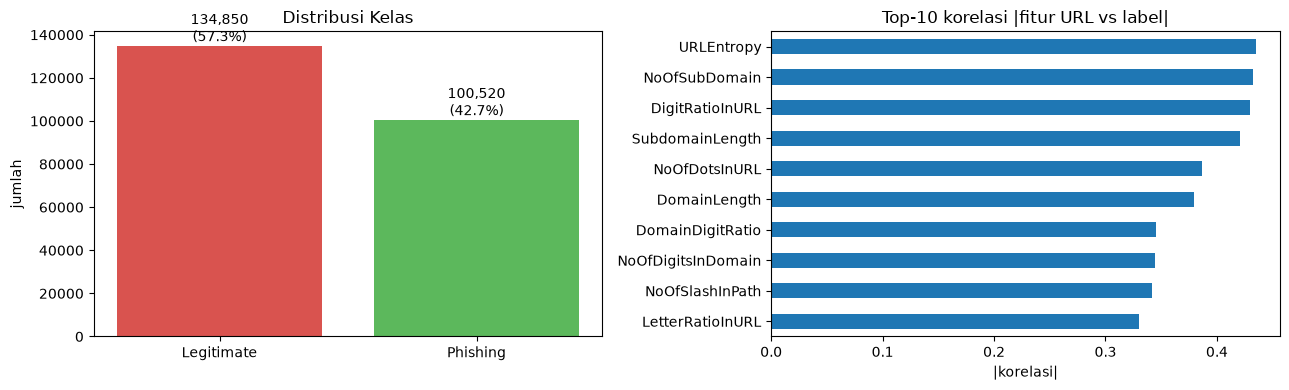

Korelasi tertinggi vs label -> X_url: 0.435 | X_full: 0.784
(keduanya <0.95 -> tidak ada fitur yang membocorkan label secara langsung)


In [5]:
# 3. EDA — distribusi kelas + korelasi fitur vs label (sanity check leakage)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
counts = pd.Series(y).map({0: 'Phishing', 1: 'Legitimate'}).value_counts()
bars = ax[0].bar(counts.index, counts.values, color=['#d9534f', '#5cb85c'])
for b, v in zip(bars, counts.values):
    ax[0].text(b.get_x() + b.get_width()/2, v, f'{v:,}\n({v/len(y)*100:.1f}%)', ha='center', va='bottom')
ax[0].set_title('Distribusi Kelas'); ax[0].set_ylabel('jumlah')

cu = X_url.assign(label=y).corr(numeric_only=True)['label'].drop('label').abs().sort_values(ascending=False)
cu.head(10).plot(kind='barh', ax=ax[1]); ax[1].invert_yaxis()
ax[1].set_title('Top-10 korelasi |fitur URL vs label|'); ax[1].set_xlabel('|korelasi|')
plt.tight_layout(); plt.show()

cf = X_full.assign(label=y).corr(numeric_only=True)['label'].drop('label').abs()
print(f'Korelasi tertinggi vs label -> X_url: {cu.max():.3f} | X_full: {cf.max():.3f}')
print('(keduanya <0.95 -> tidak ada fitur yang membocorkan label secara langsung)')

--- URL-only ---
  [URL-only]   3 fitur -> F1-phishing CV = 0.7761
  [URL-only]   5 fitur -> F1-phishing CV = 0.8036
  [URL-only]   8 fitur -> F1-phishing CV = 0.9532
  [URL-only]  10 fitur -> F1-phishing CV = 0.9606
  [URL-only]  12 fitur -> F1-phishing CV = 0.9581
  [URL-only]  15 fitur -> F1-phishing CV = 0.9617
  [URL-only]  20 fitur -> F1-phishing CV = 0.9593
  [URL-only]  41 fitur -> F1-phishing CV = 0.9532
--- FULL (URL+HTML) ---
  [FULL (URL+HTML)]   3 fitur -> F1-phishing CV = 0.9400
  [FULL (URL+HTML)]   5 fitur -> F1-phishing CV = 0.9637
  [FULL (URL+HTML)]   8 fitur -> F1-phishing CV = 0.9783
  [FULL (URL+HTML)]  10 fitur -> F1-phishing CV = 0.9789
  [FULL (URL+HTML)]  12 fitur -> F1-phishing CV = 0.9836
  [FULL (URL+HTML)]  15 fitur -> F1-phishing CV = 0.9837
  [FULL (URL+HTML)]  20 fitur -> F1-phishing CV = 0.9855
  [FULL (URL+HTML)]  58 fitur -> F1-phishing CV = 0.9862


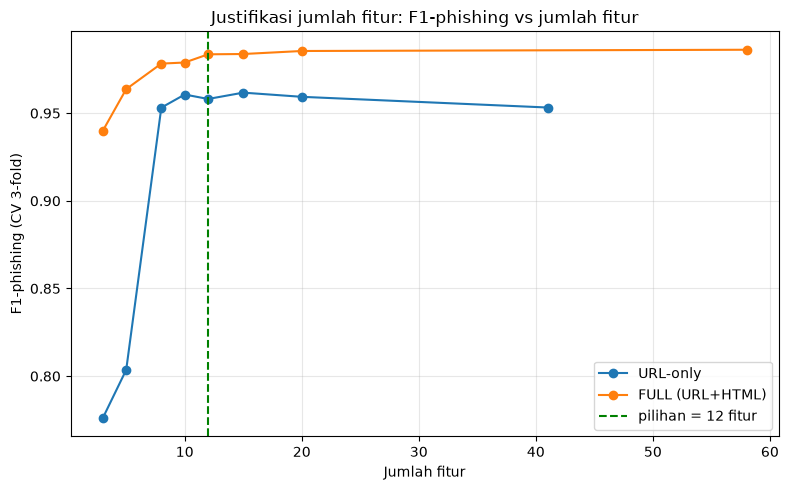


INTERPRETASI (untuk sidang):
Pilih jumlah fitur di titik kurva mulai MENDATAR (plateau). Garis hijau = 12.
Jika F1 sudah stabil di ~10-12 fitur, menambah fitur tak menaikkan performa tapi
menambah kompleksitas/overfit -> maka 12 fitur = optimal & ringkas. Sesuaikan
N_FEATURES bila plateau ternyata di angka lain (mis. 10 atau 14).


In [6]:
# 3b. JUSTIFIKASI JUMLAH FITUR — "kenapa 12?"  (kurva F1-phishing vs jumlah fitur)
#     Uji beberapa jumlah fitur via RFE + cross-validation. Pilih di titik kurva
#     sudah MENDATAR (plateau): performa optimal dgn fitur paling sedikit.
from sklearn.model_selection import cross_val_score

def kurva_jumlah_fitur(X, y, groups, nama, kandidat=(3, 5, 8, 10, 12, 15, 20)):
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(X), size=min(20000, len(X)), replace=False)   # subsample utk cepat
    Xs, ys, gs = X.iloc[idx].reset_index(drop=True), y[idx], groups[idx]
    est = xgb.XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=4,
                            subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    # Ranking semua fitur sekali pakai RFE (step=2 biar cepat)
    ranking = RFE(est, n_features_to_select=1, step=2).fit(Xs, ys).ranking_
    order = [f for _, f in sorted(zip(ranking, list(X.columns)))]      # fitur terbaik dulu
    cv = list(GroupKFold(n_splits=3).split(Xs, ys, groups=gs))
    ks = [k for k in kandidat if k <= X.shape[1]] + [X.shape[1]]
    scores = []
    for k in ks:
        s = cross_val_score(est, Xs[order[:k]], ys, cv=cv, scoring=f1_phish, n_jobs=-1).mean()
        scores.append(s)
        print(f'  [{nama}] {k:>3} fitur -> F1-phishing CV = {s:.4f}')
    return ks, scores

plt.figure(figsize=(8, 5))
for Xset, nm, col in [(X_url, 'URL-only', 'tab:blue'), (X_full, 'FULL (URL+HTML)', 'tab:orange')]:
    print(f'--- {nm} ---')
    ks, sc = kurva_jumlah_fitur(Xset, y, groups, nm)
    plt.plot(ks, sc, marker='o', label=nm, color=col)
plt.axvline(N_FEATURES, ls='--', color='green', label=f'pilihan = {N_FEATURES} fitur')
plt.xlabel('Jumlah fitur'); plt.ylabel('F1-phishing (CV 3-fold)')
plt.title('Justifikasi jumlah fitur: F1-phishing vs jumlah fitur')
plt.legend(); plt.grid(alpha=.3); plt.tight_layout(); plt.show()

print('\nINTERPRETASI (untuk sidang):')
print(f'Pilih jumlah fitur di titik kurva mulai MENDATAR (plateau). Garis hijau = {N_FEATURES}.')
print('Jika F1 sudah stabil di ~10-12 fitur, menambah fitur tak menaikkan performa tapi')
print('menambah kompleksitas/overfit -> maka 12 fitur = optimal & ringkas. Sesuaikan')
print('N_FEATURES bila plateau ternyata di angka lain (mis. 10 atau 14).')

[URL-only] RFECV pilih 15 fitur (otomatis):
   ['URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'NoOfSubDomain', 'LongestTokenLength', 'NoOfTokens', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDigitsInURL', 'DigitRatioInURL', 'NoOfDotsInURL', 'NoOfSlashInPath', 'SpecialCharRatioInURL', 'IsSuspiciousTLD']

[FULL (URL+HTML)] RFECV pilih 29 fitur (otomatis):
   ['URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'SubdomainLength', 'LongestTokenLength', 'NoOfTokens', 'LetterRatioInURL', 'NoOfDigitsInURL', 'DigitRatioInURL', 'NoOfDigitsInDomain', 'URLEntropy', 'NoOfDotsInURL', 'NoOfSlashInPath', 'SpecialCharRatioInURL', 'IsSuspiciousTLD', 'HasTitle', 'DomainTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'HasDescription', 'NoOfiFrame', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'Pay', 'Crypto', 'HasCopyrightInfo']



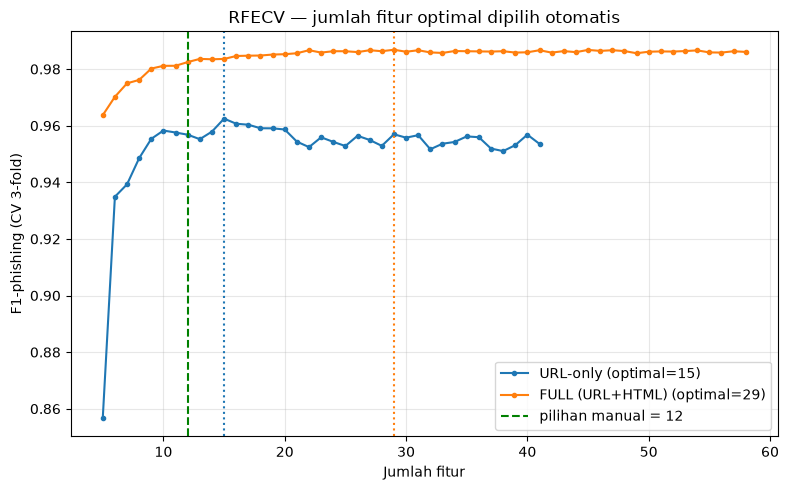

CATATAN:
- RFECV memilih jumlah fitur di skor CV TERTINGGI secara otomatis.
- Kalau RFECV pilih >14 & kamu ingin model ringkas, boleh tetap pakai RFE 12
  (kurva sel 3b) dgn alasan plateau + parsimony. Dua-duanya valid utk skripsi.


In [7]:
# 3c. ALTERNATIF: RFECV — pilih jumlah fitur OTOMATIS via cross-validation
#     RFECV = RFE + CV: ia mengevaluasi tiap jumlah fitur dgn CV lalu memilih
#     jumlah dengan skor terbaik. (Jawaban "kenapa N fitur" jadi: dipilih otomatis.)
from sklearn.feature_selection import RFECV

def rfecv(X, y, groups, nama, min_fitur=5):
    rng = np.random.RandomState(RANDOM_STATE)
    idx = rng.choice(len(X), size=min(20000, len(X)), replace=False)
    Xs, ys, gs = X.iloc[idx].reset_index(drop=True), y[idx], groups[idx]
    est = xgb.XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=4,
                            subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                            eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
    cv = list(GroupKFold(n_splits=3).split(Xs, ys, groups=gs))
    rfecv = RFECV(est, step=1, min_features_to_select=min_fitur, cv=cv, scoring=f1_phish, n_jobs=-1)
    rfecv.fit(Xs, ys)
    feats = [f for f, k in zip(X.columns, rfecv.support_) if k]
    try:
        scores = list(rfecv.cv_results_['mean_test_score'])     # sklearn >= 1.0
    except (AttributeError, KeyError):
        scores = list(rfecv.grid_scores_)                       # sklearn lama
    ks = list(range(min_fitur, min_fitur + len(scores)))
    print(f'[{nama}] RFECV pilih {rfecv.n_features_} fitur (otomatis):\n   {feats}\n')
    return ks, scores, rfecv.n_features_

plt.figure(figsize=(8, 5))
for Xset, nm, col in [(X_url, 'URL-only', 'tab:blue'), (X_full, 'FULL (URL+HTML)', 'tab:orange')]:
    ks, sc, nopt = rfecv(Xset, y, groups, nm)
    plt.plot(ks, sc, marker='.', label=f'{nm} (optimal={nopt})', color=col)
    plt.axvline(nopt, ls=':', color=col)
plt.axvline(N_FEATURES, ls='--', color='green', label=f'pilihan manual = {N_FEATURES}')
plt.xlabel('Jumlah fitur'); plt.ylabel('F1-phishing (CV 3-fold)')
plt.title('RFECV — jumlah fitur optimal dipilih otomatis'); plt.legend(); plt.grid(alpha=.3)
plt.tight_layout(); plt.show()

print('CATATAN:')
print('- RFECV memilih jumlah fitur di skor CV TERTINGGI secara otomatis.')
print('- Kalau RFECV pilih >14 & kamu ingin model ringkas, boleh tetap pakai RFE 12')
print('  (kurva sel 3b) dgn alasan plateau + parsimony. Dua-duanya valid utk skripsi.')

In [8]:
# 4. FUNGSI PIPELINE — seleksi: 'rfe' | 'rfecv' | 'group'
#    URL-only -> 'rfecv'  (RFECV pada semua fitur URL)
#    FULL     -> 'group'  (fitur dipisah URL & HTML, RFECV per-grup, lalu DIGABUNG)
from sklearn.feature_selection import RFE, RFECV

# Grup URL = 41 fitur dari url_features.py; sisanya (kolom konten dataset) = grup HTML
URL_COLS = set(URL_FEATURES)

def jalankan_pipeline(X, y, groups, nama, metode='rfe', plot=True):
    print('=' * 72)
    print(f'PIPELINE: {nama}  | fitur awal: {X.shape[1]}  | seleksi: {metode.upper()}')
    print('=' * 72)

    # (1) Split per-domain
    gss = GroupShuffleSplit(n_splits=1, test_size=TEST_SIZE, random_state=RANDOM_STATE)
    tr, te = next(gss.split(X, y, groups=groups))
    Xtr, Xte = X.iloc[tr].reset_index(drop=True), X.iloc[te].reset_index(drop=True)
    ytr, yte = y[tr], y[te]
    gtr = groups[tr]
    assert len(set(gtr) & set(groups[te])) == 0, 'Domain bocor!'
    spw = 1.0

    rng = np.random.RandomState(RANDOM_STATE)
    si = rng.choice(len(Xtr), size=min(50000, len(Xtr)), replace=False)

    def _rfecv_cols(cols, min_feat):
        """RFECV pada subset kolom tertentu -> daftar fitur terpilih."""
        e = xgb.XGBClassifier(n_estimators=150, learning_rate=0.1, max_depth=4,
                              subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                              eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
        r = RFECV(e, step=1, min_features_to_select=min(min_feat, len(cols)),
                  cv=list(GroupKFold(n_splits=3).split(Xtr[cols].iloc[si], ytr[si], groups=gtr[si])),
                  scoring=f1_phish, n_jobs=-1)
        r.fit(Xtr[cols].iloc[si], ytr[si])
        return [f for f, k in zip(cols, r.support_) if k]

    # (2) SELEKSI FITUR
    if metode == 'group':
        url_g  = [c for c in X.columns if c in URL_COLS]
        html_g = [c for c in X.columns if c not in URL_COLS]
        url_sel  = _rfecv_cols(url_g, 3) if url_g else []
        html_sel = _rfecv_cols(html_g, 3) if html_g else []
        feats = url_sel + html_sel
        print(f'GROUP-RFECV -> {len(url_sel)} URL + {len(html_sel)} HTML = {len(feats)} fitur')
        print(f'  URL : {url_sel}')
        print(f'  HTML: {html_sel}')
    elif metode == 'rfecv':
        feats = _rfecv_cols(list(X.columns), 8)
        print(f'RFECV -> {len(feats)} fitur: {feats}')
    else:  # 'rfe'
        base = xgb.XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                                 subsample=0.8, colsample_bytree=0.8, tree_method='hist',
                                 eval_metric='logloss', random_state=RANDOM_STATE, n_jobs=-1)
        rfe = RFE(base, n_features_to_select=min(N_FEATURES, X.shape[1]), step=1)
        rfe.fit(Xtr.iloc[si], ytr[si])
        feats = [f for f, k in zip(X.columns, rfe.support_) if k]
        print(f'RFE -> {len(feats)} fitur: {feats}')

    Xtr, Xte = Xtr[feats], Xte[feats]

    # (3) Tuning hyperparameter domain-aware (GroupKFold, F1-phishing)
    ti = rng.choice(len(Xtr), size=min(60000, len(Xtr)), replace=False)
    param = {'n_estimators': [300, 400, 500, 600], 'learning_rate': [0.03, 0.05, 0.08, 0.1],
             'max_depth': [4, 5, 6, 7, 8], 'min_child_weight': [1, 3, 5, 7],
             'subsample': [0.7, 0.8, 0.9, 1.0], 'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
             'gamma': [0, 0.1, 0.2, 0.3], 'reg_alpha': [0, 0.1, 0.5, 1.0], 'reg_lambda': [1.0, 2.0, 3.0]}
    srch = RandomizedSearchCV(
        xgb.XGBClassifier(eval_metric='logloss', tree_method='hist', scale_pos_weight=spw,
                          random_state=RANDOM_STATE, n_jobs=1),
        param, n_iter=20, scoring=f1_phish,
        cv=list(GroupKFold(n_splits=3).split(Xtr.iloc[ti], ytr[ti], groups=gtr[ti])),
        n_jobs=-1, random_state=RANDOM_STATE)
    srch.fit(Xtr.iloc[ti], ytr[ti])
    bp = srch.best_params_
    print(f'Best params: {bp}')

    # (4) Train final + early stopping (validasi per-domain)
    gv = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
    ai, vi = next(gv.split(Xtr, ytr, groups=gtr))
    fp = dict(n_estimators=1000, learning_rate=0.05, max_depth=6, min_child_weight=5,
              subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0, gamma=0.1)
    fp.update(bp); fp['n_estimators'] = max(fp.get('n_estimators', 600), 1000)
    model = xgb.XGBClassifier(**fp, scale_pos_weight=spw, eval_metric='logloss',
                              early_stopping_rounds=50, tree_method='hist',
                              importance_type='gain', random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(Xtr.iloc[ai], ytr[ai], eval_set=[(Xtr.iloc[vi], ytr[vi])], verbose=False)

    # (5) Optimasi threshold di VALIDASI — balanced accuracy (anti "semua phishing")
    from sklearn.metrics import balanced_accuracy_score
    vp = model.predict_proba(Xtr.iloc[vi])[:, 0]
    cand = np.linspace(0.2, 0.8, 61)
    bacc = [balanced_accuracy_score(ytr[vi], np.where(vp >= t, 0, 1)) for t in cand]
    thr = float(cand[int(np.argmax(bacc))])

    # (6) Evaluasi + gap train vs test
    acc_tr = accuracy_score(ytr[ai], model.predict(Xtr.iloc[ai]))
    pph = model.predict_proba(Xte)[:, 0]
    yp = np.where(pph >= thr, 0, 1)
    acc = accuracy_score(yte, yp)
    pr = precision_score(yte, yp, pos_label=0)
    re = recall_score(yte, yp, pos_label=0)
    f1 = f1_score(yte, yp, pos_label=0)
    yi = (yte == 0).astype(int)
    fpr, tpr, _ = roc_curve(yi, pph); rocauc = auc(fpr, tpr)
    gap = abs(acc_tr - acc)
    print(f'\n[{nama}] thr={thr:.3f} | Acc train={acc_tr:.4f} test={acc:.4f} '
          f'(gap={gap*100:.2f}% {"OK" if gap < 0.05 else "PERHATIKAN overfit"})')
    print(f'[{nama}] Phishing: P={pr:.4f} R={re:.4f} F1={f1:.4f} | ROC-AUC={rocauc:.4f}')
    print(classification_report(yte, yp, target_names=['Phishing(0)', 'Legitimate(1)']))

    if plot:
        cm = confusion_matrix(yte, yp, labels=[0, 1])
        fig, a = plt.subplots(1, 2, figsize=(11, 4))
        ConfusionMatrixDisplay(cm, display_labels=['Phish', 'Legit']).plot(ax=a[0], cmap='Blues', colorbar=False)
        a[0].set_title(f'Confusion Matrix - {nama}')
        a[1].plot(fpr, tpr, label=f'AUC={rocauc:.3f}'); a[1].plot([0, 1], [0, 1], '--', color='gray')
        a[1].set_title(f'ROC - {nama}'); a[1].set_xlabel('FPR'); a[1].set_ylabel('TPR'); a[1].legend()
        plt.tight_layout(); plt.show()

    return {'nama': nama, 'model': model, 'fitur': feats, 'threshold': thr,
            'acc': acc, 'acc_train': acc_tr, 'gap': gap,
            'precision': pr, 'recall': re, 'f1': f1, 'roc_auc': rocauc, 'n_fitur': len(feats)}

print('Fungsi jalankan_pipeline siap (metode: rfe / rfecv / group).')

Fungsi jalankan_pipeline siap (metode: rfe / rfecv / group).


PIPELINE: URL-only  | fitur awal: 41  | seleksi: RFECV
RFECV -> 16 fitur: ['URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'NoOfSubDomain', 'LongestTokenLength', 'NoOfTokens', 'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDigitsInURL', 'DigitRatioInURL', 'NoOfDotsInURL', 'NoOfSlashInPath', 'SpecialCharRatioInURL', 'HasSuspiciousWord', 'IsSuspiciousTLD']
Best params: {'subsample': 0.7, 'reg_lambda': 1.0, 'reg_alpha': 1.0, 'n_estimators': 600, 'min_child_weight': 3, 'max_depth': 8, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.9}

[URL-only] thr=0.380 | Acc train=0.9850 test=0.9755 (gap=0.95% OK)
[URL-only] Phishing: P=0.9918 R=0.9587 F1=0.9750 | ROC-AUC=0.9938
               precision    recall  f1-score   support

  Phishing(0)       0.99      0.96      0.97     26452
Legitimate(1)       0.96      0.99      0.98     26771

     accuracy                           0.98     53223
    macro avg       0.98      0.98      0.98     53223
 weighted avg       0.98      0.98   

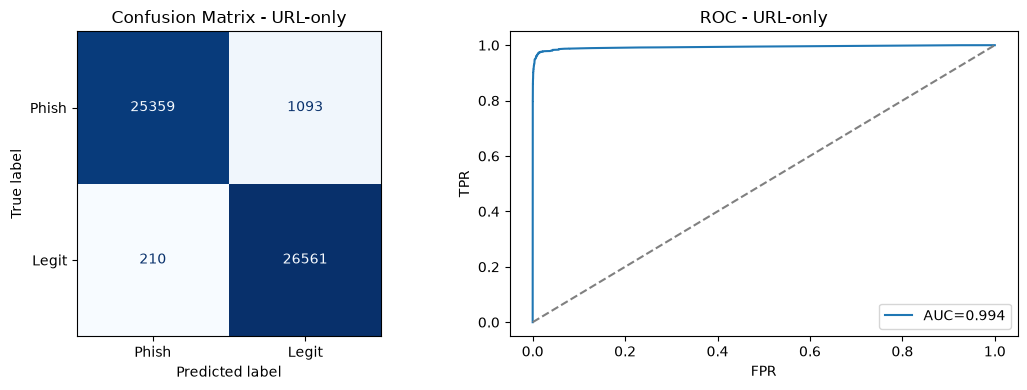

In [9]:
# 5. MODEL URL-only (seleksi = RFECV) — untuk PERBANDINGAN saja
#    Catatan: skripsi_final HANYA meng-export model gabungan (FULL).
#    pkl model URL-only dihasilkan oleh skripsi.ipynb.
res_url = jalankan_pipeline(X_url, y, groups, 'URL-only', metode='rfecv')

PIPELINE: FULL (URL+HTML)  | fitur awal: 58  | seleksi: RFECV
RFECV -> 27 fitur: ['URLLength', 'DomainLength', 'TLDLength', 'PathLength', 'SubdomainLength', 'LongestTokenLength', 'NoOfTokens', 'NoOfLettersInURL', 'NoOfDigitsInURL', 'DigitRatioInURL', 'URLEntropy', 'NoOfDotsInURL', 'NoOfSlashInPath', 'HasSuspiciousWord', 'IsSuspiciousTLD', 'HasTitle', 'DomainTitleMatchScore', 'HasFavicon', 'Robots', 'IsResponsive', 'HasDescription', 'NoOfiFrame', 'HasSocialNet', 'HasSubmitButton', 'HasHiddenFields', 'Pay', 'HasCopyrightInfo']
Best params: {'subsample': 1.0, 'reg_lambda': 1.0, 'reg_alpha': 0, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 7, 'learning_rate': 0.05, 'gamma': 0.3, 'colsample_bytree': 0.9}

[FULL (URL+HTML)] thr=0.380 | Acc train=0.9974 test=0.9960 (gap=0.14% OK)
[FULL (URL+HTML)] Phishing: P=0.9964 R=0.9955 F1=0.9960 | ROC-AUC=0.9999
               precision    recall  f1-score   support

  Phishing(0)       1.00      1.00      1.00     26452
Legitimate(1)       1

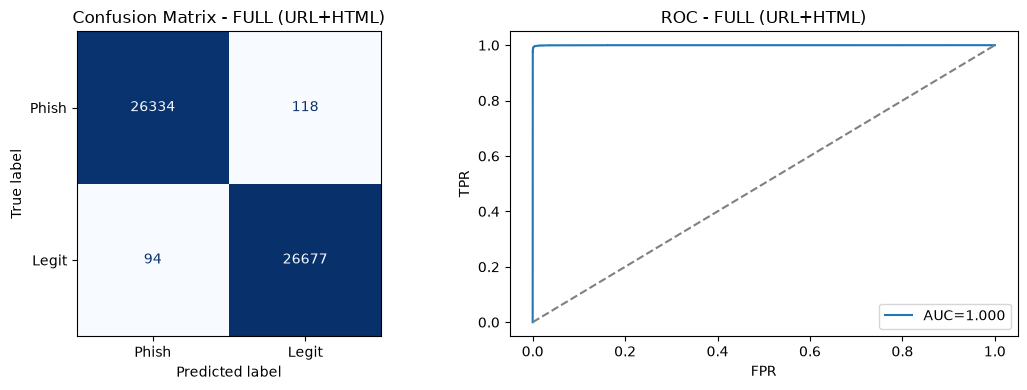


Export FULL OK: model_xgboost_dataset.pkl, dataset_feature_schema.pkl, dataset_threshold.pkl


In [10]:
# 6. JALANKAN MODEL FULL (URL+HTML, seleksi = RFECV pada semua fitur — cara sel 3c) -> export
#    RFECV dijalankan di DATA TRAINING saja (anti-leakage). Sel 3c hanya eksplorasi/justifikasi.
res_full = jalankan_pipeline(X_full, y, groups, 'FULL (URL+HTML)', metode='rfecv')

joblib.dump(res_full['model'], 'model_xgboost_dataset.pkl')
joblib.dump(res_full['fitur'], 'dataset_feature_schema.pkl')
joblib.dump(res_full['threshold'], 'dataset_threshold.pkl')
print('\nExport FULL OK: model_xgboost_dataset.pkl, dataset_feature_schema.pkl, dataset_threshold.pkl')

          Model  #Fitur  Akurasi  Precision_phish  Recall_phish  F1_phish  ROC_AUC  Threshold
       URL-only      16   0.9755           0.9918        0.9587     0.975   0.9938       0.38
FULL (URL+HTML)      27   0.9960           0.9964        0.9955     0.996   0.9999       0.38


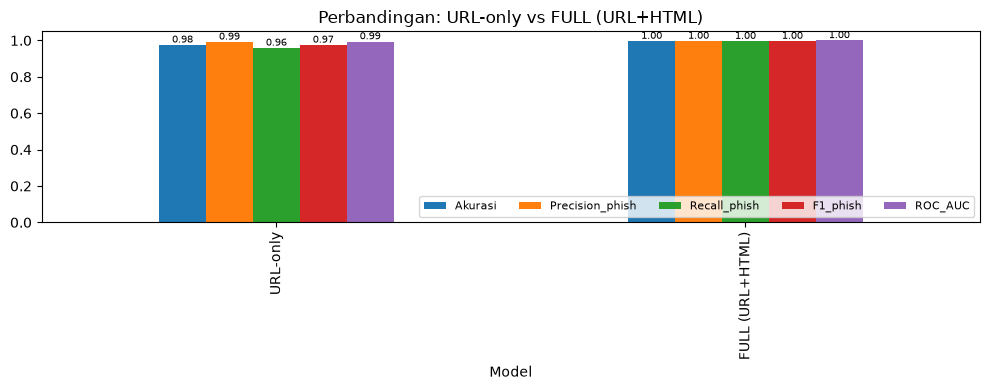


Catatan: FULL biasanya lebih tinggi DI DATASET, tapi fitur kontennya sulit
direproduksi live (skew). Backend: FULL saat scrape sukses, fallback URL-only saat gagal.


In [13]:
# 7. TABEL PERBANDINGAN URL-only vs FULL  (bahan bab hasil)
cmp = pd.DataFrame([res_url, res_full])[
    ['nama', 'n_fitur', 'acc', 'precision', 'recall', 'f1', 'roc_auc', 'threshold']]
cmp.columns = ['Model', '#Fitur', 'Akurasi', 'Precision_phish', 'Recall_phish', 'F1_phish', 'ROC_AUC', 'Threshold']
print(cmp.round(4).to_string(index=False))

ax = cmp.set_index('Model')[['Akurasi', 'Precision_phish', 'Recall_phish', 'F1_phish', 'ROC_AUC']].plot(
    kind='bar', figsize=(10, 4), ylim=(0, 1.05))
ax.set_title('Perbandingan: URL-only vs FULL (URL+HTML)')
ax.legend(loc='lower right', ncol=5, fontsize=8)
for c in ax.containers:
    ax.bar_label(c, fmt='%.2f', fontsize=7)
plt.tight_layout(); plt.show()

print('\nCatatan: FULL biasanya lebih tinggi DI DATASET, tapi fitur kontennya sulit')
print('direproduksi live (skew). Backend: FULL saat scrape sukses, fallback URL-only saat gagal.')

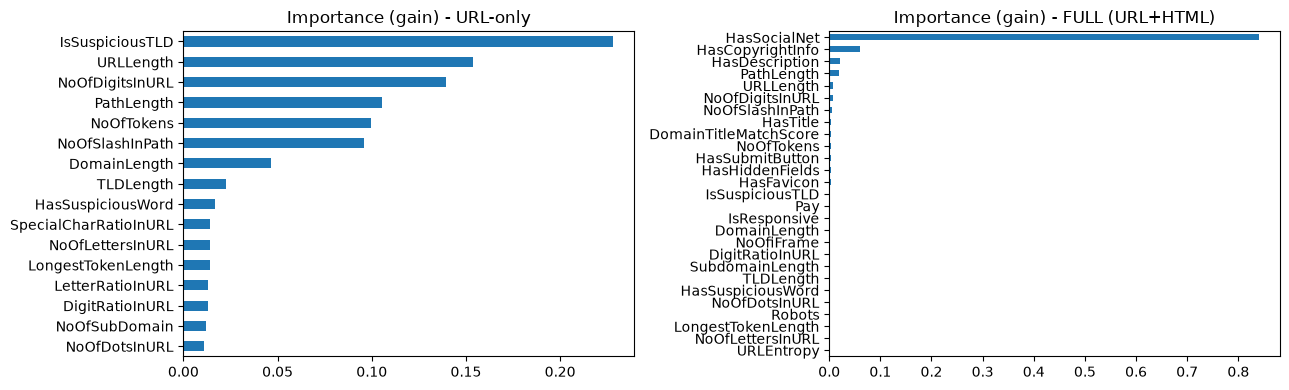

SHAP model FULL (SHAP>0 dorong legit, <0 dorong phishing):


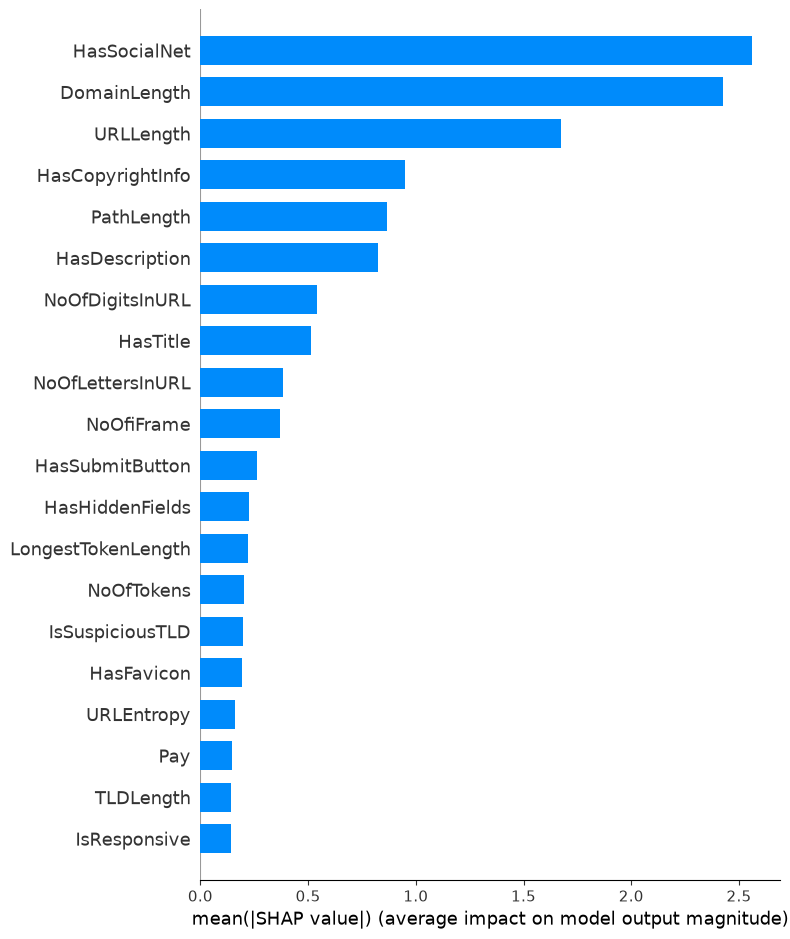

In [14]:
# 8. FEATURE IMPORTANCE (gain) kedua model + SHAP (opsional)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
for axx, res in zip(ax, [res_url, res_full]):
    imp = pd.Series(res['model'].feature_importances_, index=res['fitur']).sort_values()
    imp.plot(kind='barh', ax=axx); axx.set_title(f"Importance (gain) - {res['nama']}")
plt.tight_layout(); plt.show()

# SHAP untuk model FULL (penjelasan kenapa sebuah prediksi)
try:
    import shap
    Xs = X_full[res_full['fitur']].sample(min(1500, len(X_full)), random_state=RANDOM_STATE)
    sv = shap.TreeExplainer(res_full['model']).shap_values(Xs)
    print('SHAP model FULL (SHAP>0 dorong legit, <0 dorong phishing):')
    shap.summary_plot(sv, Xs, plot_type='bar', show=True)
except ImportError:
    print('(SHAP dilewati — jalankan: pip install shap)')

In [15]:
# 9. SIMULASI BACKEND end-to-end (persis logika app.py)
#    allowlist -> FULL (url_features + scrape HTML) -> fallback URL-only
import importlib, phiusiil_live
importlib.reload(phiusiil_live)
from phiusiil_live import scrape_html_features

ALLOWLIST = {'google.com', 'youtube.com', 'github.com', 'amazon.com', 'wikipedia.org',
             'paypal.com', 'facebook.com', 'bankmandiri.co.id', 'tokopedia.com', 'claude.ai'}

def prediksi_backend(url):
    u = normalize_url(url)
    dom = extract_registered_domain(u)
    if dom in ALLOWLIST:
        return 'legitimate', 'allowlist', None
    uf = extract_url_features(u)                        # 41 fitur URL (konsisten train<->serve)
    html = scrape_html_features(u, timeout=10)          # fitur HTML hasil scrape (atau None)
    if html is not None:
        feats = {**uf, **html}
        p = float(res_full['model'].predict_proba(pd.DataFrame([feats])[res_full['fitur']])[0][0])
        return ('phishing' if p >= res_full['threshold'] else 'legitimate'), 'full(URL+HTML)', round(p, 3)
    p = float(res_url['model'].predict_proba(pd.DataFrame([uf])[res_url['fitur']])[0][0])
    return ('phishing' if p >= res_url['threshold'] else 'legitimate'), 'url_only(fallback)', round(p, 3)

uji = ['https://search.worldcat.org/', 'https://overleaf.com', 'https://pornhub,com',
       'http://login-verify-account.security-update.tk/webscr?cmd=update', "https://chatgpt.com/",
       'http://192.168.0.10/confirm-account/update.php']
for u in uji:
    hasil, mode, p = prediksi_backend(u)
    print(f'{u[:52]:52} -> {hasil:11} | mode={mode:18} | P(phish)={p}')

https://search.worldcat.org/                         -> phishing    | mode=url_only(fallback) | P(phish)=0.528
https://overleaf.com                                 -> legitimate  | mode=full(URL+HTML)     | P(phish)=0.0
https://pornhub,com                                  -> legitimate  | mode=url_only(fallback) | P(phish)=0.052
http://login-verify-account.security-update.tk/websc -> phishing    | mode=url_only(fallback) | P(phish)=1.0
https://chatgpt.com/                                 -> legitimate  | mode=full(URL+HTML)     | P(phish)=0.025
http://192.168.0.10/confirm-account/update.php       -> phishing    | mode=url_only(fallback) | P(phish)=1.0


In [16]:
# 10. EVALUASI ROBUST — GroupKFold 5-fold cross-validation (bukan cuma 1 split)
#     Membuktikan performa STABIL (mean ± std), bukan kebetulan satu pembagian data.
from sklearn.model_selection import cross_val_score

rng = np.random.RandomState(RANDOM_STATE)
sub = rng.choice(len(y), size=min(80000, len(y)), replace=False)   # subsample agar tak terlalu lama
gkf5 = GroupKFold(n_splits=5)

for res, Xset in [(res_url, X_url), (res_full, X_full)]:
    Xs = Xset[res['fitur']].iloc[sub]
    ys, gs = y[sub], groups[sub]
    est = xgb.XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=6,
                            subsample=0.8, colsample_bytree=0.8, reg_alpha=0.5, reg_lambda=2.0,
                            tree_method='hist', eval_metric='logloss',
                            random_state=RANDOM_STATE, n_jobs=-1)
    cv = list(gkf5.split(Xs, ys, groups=gs))
    f1s  = cross_val_score(est, Xs, ys, cv=cv, scoring=f1_phish, n_jobs=-1)
    aucs = cross_val_score(est, Xs, ys, cv=cv, scoring='roc_auc', n_jobs=-1)
    print(f"[{res['nama']:16}] 5-fold CV  F1-phishing = {f1s.mean():.4f} ± {f1s.std():.4f}  |  "
          f"ROC-AUC = {aucs.mean():.4f} ± {aucs.std():.4f}")

print('\nStd kecil = model STABIL (tidak overfit ke satu split). Bahan kuat untuk bab hasil.')

[URL-only        ] 5-fold CV  F1-phishing = 0.9762 ± 0.0043  |  ROC-AUC = 0.9921 ± 0.0006
[FULL (URL+HTML) ] 5-fold CV  F1-phishing = 0.9916 ± 0.0011  |  ROC-AUC = 0.9997 ± 0.0001

Std kecil = model STABIL (tidak overfit ke satu split). Bahan kuat untuk bab hasil.


## Selesai — file yang dihasilkan

| Sumber | pkl |
|---|---|
| **`skripsi_final.ipynb`** (notebook ini) | `model_xgboost_dataset.pkl`, `dataset_feature_schema.pkl`, `dataset_threshold.pkl` (model **FULL**) |
| **`skripsi.ipynb`** | `model_xgboost_url.pkl`, `url_feature_schema.pkl`, `decision_threshold.pkl` (model **URL-only**) |

**Backend (`app.py`):** `allowlist → FULL (extract_url_features + scrape_html_features) → fallback URL-only`.

**Untuk skripsi:** sel 7 = tabel perbandingan URL-only vs FULL; sel 8 = importance/SHAP; sel 9 = bukti sistem end-to-end (termasuk `claude.ai` vs `claude.ai/` yang kini identik berkat normalisasi trailing slash).

> Karena `url_features.py` (normalisasi trailing slash) berubah, **jalankan ulang `skripsi.ipynb` & `skripsi_final.ipynb`** agar pkl konsisten dengan backend.